<a href="https://colab.research.google.com/github/ElianaHeitner/CNN-and-MLP-project/blob/main/task2_mlp_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2. Comparison to MLP

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

In [4]:
#Basic transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [5]:
#Download Dataset

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:01<00:00, 97.8MB/s]


In [6]:
# Creat DataLoaders

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

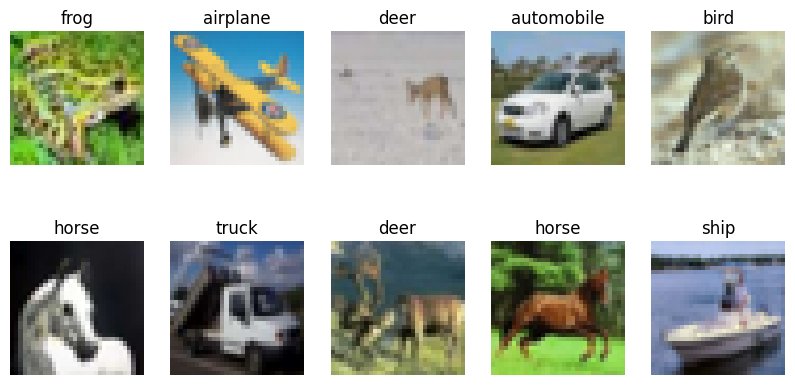

In [7]:

# CNN Sarter code

classes = train_dataset.classes

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):

    img = images[i] / 2 + 0.5
    img = img.permute(1, 2, 0)

    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis('off')

plt.show()



In [8]:
class InitialCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)

        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):

        x = torch.sigmoid(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = torch.sigmoid(self.conv4(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)

        x = torch.sigmoid(self.fc1(x))
        x = self.fc2(x)

        return x

In [9]:
# Initialize Network

model = InitialCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [10]:
# Training function

def train(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    gradient_norms = {}

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        # Save gradient norms
        for name, param in model.named_parameters():

            if param.grad is not None:

                grad_norm = param.grad.norm().item()

                if name not in gradient_norms:
                    gradient_norms[name] = []

                gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy, gradient_norms

In [11]:
# Testing function

def test(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy

In [14]:
# MLP model for CIFAR-10 classification

class InitialMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):

        # Flatten image from 3 x 32 x 32 into one long vector
        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [ ]:
# Main training loop

mlp_model = InitialMLP().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    mlp_model.parameters(),
    lr=0.001
)
# Main training loop for MLP

num_epochs = 15

mlp_train_losses = []
mlp_test_losses = []

mlp_train_accs = []
mlp_test_accs = []

for epoch in range(num_epochs):

    train_loss, train_acc, grad_norms = train(
        mlp_model,
        train_loader
    )

    test_loss, test_acc = test(
        mlp_model,
        test_loader
    )

    mlp_train_losses.append(train_loss)
    mlp_test_losses.append(test_loss)

    mlp_train_accs.append(train_acc)
    mlp_test_accs.append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"MLP Train Loss: {train_loss:.4f}")
    print(f"MLP Train Accuracy: {train_acc:.2f}%")
    print(f"MLP Test Loss: {test_loss:.4f}")
    print(f"MLP Test Accuracy: {test_acc:.2f}%")
    print("-" * 40)


# Prepare epoch numbers for MLP plots
epochs = range(1, num_epochs + 1)

print("Saved MLP values check:")
print("Number of MLP train losses:", len(mlp_train_losses))
print("Number of MLP test losses:", len(mlp_test_losses))
print("Number of MLP train accuracies:", len(mlp_train_accs))
print("Number of MLP test accuracies:", len(mlp_test_accs))

Epoch 1/15
MLP Train Loss: 1.6257
MLP Train Accuracy: 42.42%
MLP Test Loss: 1.4990
MLP Test Accuracy: 46.82%
----------------------------------------
Epoch 2/15
MLP Train Loss: 1.4112
MLP Train Accuracy: 50.34%
MLP Test Loss: 1.3993
MLP Test Accuracy: 51.34%
----------------------------------------
Epoch 3/15
MLP Train Loss: 1.2952
MLP Train Accuracy: 54.53%
MLP Test Loss: 1.3628
MLP Test Accuracy: 52.54%
----------------------------------------
Epoch 4/15
MLP Train Loss: 1.2009
MLP Train Accuracy: 57.64%
MLP Test Loss: 1.3816
MLP Test Accuracy: 52.25%
----------------------------------------
Epoch 5/15
MLP Train Loss: 1.1135
MLP Train Accuracy: 60.90%
MLP Test Loss: 1.3434
MLP Test Accuracy: 53.60%
----------------------------------------
Epoch 6/15
MLP Train Loss: 1.0310
MLP Train Accuracy: 63.50%
MLP Test Loss: 1.3546
MLP Test Accuracy: 54.56%
----------------------------------------
Epoch 7/15
MLP Train Loss: 0.9557
MLP Train Accuracy: 66.17%
MLP Test Loss: 1.4041
MLP Test Accuracy

In [ ]:
print("Saved MLP values check:")
print("Number of MLP train losses:", len(mlp_train_losses))
print("Number of MLP test losses:", len(mlp_test_losses))
print("Number of MLP train accuracies:", len(mlp_train_accs))
print("Number of MLP test accuracies:", len(mlp_test_accs))

In [ ]:
# Prepare epoch numbers for plots
epochs = range(1, len(mlp_train_losses) + 1)

In [ ]:
# Plot 1: MLP Loss learning curve

plt.figure(figsize=(8, 5))

plt.plot(epochs, mlp_train_losses, label="MLP Train Loss")
plt.plot(epochs, mlp_test_losses, label="MLP Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP - Loss Across Epochs")
plt.legend()
plt.grid(True)

plt.savefig("mlp_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Plot 2: MLP Accuracy learning curve

plt.figure(figsize=(8, 5))

plt.plot(epochs, mlp_train_accs, label="MLP Train Accuracy")
plt.plot(epochs, mlp_test_accs, label="MLP Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("MLP - Accuracy Across Epochs")
plt.legend()
plt.grid(True)

plt.savefig("mlp_accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Final comparison between CNN and MLP

cnn_final_test_acc = 63.89   # from Task 1 InitialCNN
mlp_final_test_acc = mlp_test_accs[-1]

print("Final Test Accuracy Comparison")
print(f"CNN Final Test Accuracy: {cnn_final_test_acc:.2f}%")
print(f"MLP Final Test Accuracy: {mlp_final_test_acc:.2f}%")

In [ ]:
# Plot 3: CNN vs MLP final test accuracy

models = ["CNN", "MLP"]
test_accuracies = [cnn_final_test_acc, mlp_final_test_acc]

plt.figure(figsize=(6, 5))

plt.bar(models, test_accuracies)

plt.xlabel("Model")
plt.ylabel("Final Test Accuracy (%)")
plt.title("CNN vs MLP - Final Test Accuracy")
plt.ylim(0, 100)
plt.grid(axis="y")

plt.savefig("cnn_vs_mlp_test_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
print("MLP Final Results")
print(f"Final Training Loss: {mlp_train_losses[-1]:.4f}")
print(f"Final Training Accuracy: {mlp_train_accs[-1]:.2f}%")
print(f"Final Test Loss: {mlp_test_losses[-1]:.4f}")
print(f"Final Test Accuracy: {mlp_test_accs[-1]:.2f}%")